# Paralog Dependency Analysis

Comparison of **significant** vs **non-significant** paralog pairs across four molecular properties:

| Analysis | Dataset |
|---|---|
| RNA half-life | Schwanhausser et al. 2011 (*Nature*, mouse ESC) |
| Protein half-life | Schwanhausser et al. 2011 (*Nature*, mouse ESC) |
| Protein localisation | Human Protein Atlas v25 (subcellular_location.tsv) |
| Mono-allelic expression | MaGIC / Nag et al. 2013 (*eLife*) – chromatin-based classifier |

**Gene groups:**
- **Significant (sig):** 37 paralog pairs (`dep_gene`, `paralog_gene`) from `sig_37_paralog copy.xlsx`
- **Non-significant (non-sig):** 28,103 paralog pairs (`hgnc_symbol`, `para_gene_2`) from `non_sig_paralog copy.xlsx` (deduplicated)

**Pair-level approach:** For each pair, both genes' properties are retrieved; pair-level metrics (e.g., within-pair half-life difference, location Jaccard similarity) are computed and compared between groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SIG_COLOR   = '#E74C3C'   # red  – significant pairs
NSIG_COLOR  = '#3498DB'   # blue – non-significant pairs

DATA_DIR = 'data/'
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1 · Load Paralog Lists

In [2]:
# ── Significant pairs ────────────────────────────────────────────────────────
sig = pd.read_excel('sig_37_paralog copy.xlsx')
sig_pairs = sig[['dep_gene', 'paralog_gene']].copy()
sig_pairs.columns = ['gene_A', 'gene_B']
sig_pairs['group'] = 'Significant'

# ── Non-significant pairs ────────────────────────────────────────────────────
non_sig = pd.read_excel('non_sig_paralog copy.xlsx')
# Each row: hgnc_symbol ↔ para_gene_2 (para_gene_1 == hgnc_symbol always)
ns_pairs = non_sig[['hgnc_symbol', 'para_gene_2']].drop_duplicates().copy()
ns_pairs.columns = ['gene_A', 'gene_B']
ns_pairs['group'] = 'Non-significant'

# ── Combined ─────────────────────────────────────────────────────────────────
all_pairs = pd.concat([sig_pairs, ns_pairs], ignore_index=True)

print(f'Significant pairs:     {len(sig_pairs):>6,}')
print(f'Non-significant pairs: {len(ns_pairs):>6,}')
print(f'Total pairs:           {len(all_pairs):>6,}')

Significant pairs:         37
Non-significant pairs: 28,103
Total pairs:           28,140


## 2 · RNA Half-Life & Protein Half-Life Data

**Source:** Schwanhausser et al. (2011) *Nature* 473, 337–342.  
Mouse NIH3T3 / ES cell proteome-scale measurements. Human–mouse gene name matching is done case-insensitively.

In [3]:
# Load Schwanhausser 2011
schwann = pd.read_csv(DATA_DIR + 'Nature_2011_Cell.csv')

# Build gene → half-life dicts (case-insensitive, take first occurrence per gene)
gene_to_phl: dict[str, float] = {}
gene_to_rhl: dict[str, float] = {}

for _, row in schwann.iterrows():
    if pd.isna(row['Gene Names']):
        continue
    for g in str(row['Gene Names']).split(';'):
        key = g.strip().upper()
        if key and key not in gene_to_phl and pd.notna(row['Protein half-life average [h]']):
            gene_to_phl[key] = float(row['Protein half-life average [h]'])
        if key and key not in gene_to_rhl and pd.notna(row['mRNA half-life average [h]']):
            gene_to_rhl[key] = float(row['mRNA half-life average [h]'])

print(f'Genes with protein HL data: {len(gene_to_phl):,}')
print(f'Genes with mRNA HL data:    {len(gene_to_rhl):,}')


def build_hl_pairs(pairs_df: pd.DataFrame, hl_dict: dict) -> pd.DataFrame:
    """Return subset of pairs where BOTH genes have half-life data."""
    rows = []
    for _, row in pairs_df.iterrows():
        gA = str(row['gene_A']).upper()
        gB = str(row['gene_B']).upper()
        hlA = hl_dict.get(gA)
        hlB = hl_dict.get(gB)
        if hlA is not None and hlB is not None:
            rows.append({
                'gene_A': row['gene_A'], 'gene_B': row['gene_B'],
                'group': row['group'],
                'hl_A': hlA, 'hl_B': hlB,
                'hl_mean': (hlA + hlB) / 2,
                'hl_diff': abs(hlA - hlB),
            })
    return pd.DataFrame(rows)


phl_pairs = build_hl_pairs(all_pairs, gene_to_phl)
rhl_pairs = build_hl_pairs(all_pairs, gene_to_rhl)

for label, df in [('Protein HL', phl_pairs), ('mRNA HL', rhl_pairs)]:
    sig_n  = (df['group'] == 'Significant').sum()
    nsig_n = (df['group'] == 'Non-significant').sum()
    print(f'{label} — sig pairs: {sig_n}, non-sig pairs: {nsig_n}')

Genes with protein HL data: 9,945
Genes with mRNA HL data:    9,313


Protein HL — sig pairs: 19, non-sig pairs: 2148
mRNA HL — sig pairs: 18, non-sig pairs: 1953


## 3 · Mono-Allelic Expression Data

**Source:** Nag et al. (2013) *eLife* – MaGIC chromatin-based classifier.  
H3K27me3 and H3K36me3 percentile scores from GM12878 lymphoblastoid cells.  
A logistic regression is trained on labeled genes (1,287 from `human_tg.tsv` + 1,380 from `testing_human_2015.tsv`) and applied to all 24,378 scored genes.

In [4]:
# ── Load labeled MAE/BAE data ─────────────────────────────────────────────────
tg   = pd.read_csv(DATA_DIR + 'mae_human_tg.tsv',        sep='\t')
test = pd.read_csv(DATA_DIR + 'mae_testing_human_2015.tsv', sep='\t')
scores = pd.read_csv(DATA_DIR + 'mae_joined_scores_GM12878.txt', sep='\t')

# Combine labeled datasets (deduplicate by gene, prefer tg)
labeled_tg   = tg[['gene', 'status']].copy()
labeled_test = test[['gene', 'status']].copy()
labeled = pd.concat([labeled_tg, labeled_test]).drop_duplicates(subset='gene')
labeled['mae_label'] = (labeled['status'] == 'MAE').astype(int)

print(f'Labeled genes: {len(labeled):,}  (MAE: {labeled["mae_label"].sum()}, BAE: {(labeled["mae_label"]==0).sum()})')

# ── Merge labels with chromatin scores ───────────────────────────────────────
scores_upper = scores.copy()
scores_upper['name_upper'] = scores_upper['name'].str.upper()
labeled['gene_upper'] = labeled['gene'].str.upper()

train_df = scores_upper.merge(
    labeled[['gene_upper', 'mae_label']],
    left_on='name_upper', right_on='gene_upper'
).dropna(subset=['h3k27me3_percentile', 'h3k36me3_percentile'])

print(f'Genes with both scores AND labels: {len(train_df):,}')

# ── Train logistic regression ─────────────────────────────────────────────────
X_train = train_df[['h3k27me3_percentile', 'h3k36me3_percentile']].values
y_train = train_df['mae_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

clf = LogisticRegression(random_state=42, max_iter=1000)
cv_scores = cross_val_score(clf, X_scaled, y_train, cv=5, scoring='roc_auc')
clf.fit(X_scaled, y_train)

print(f'Logistic regression 5-fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# ── Predict MAE for all scored genes ─────────────────────────────────────────
all_scores = scores_upper.dropna(subset=['h3k27me3_percentile', 'h3k36me3_percentile'])
X_all = scaler.transform(all_scores[['h3k27me3_percentile', 'h3k36me3_percentile']].values)
all_scores = all_scores.copy()
all_scores['mae_pred'] = clf.predict(X_all)
all_scores['mae_prob'] = clf.predict_proba(X_all)[:, 1]

gene_to_mae: dict[str, int] = dict(
    zip(all_scores['name_upper'], all_scores['mae_pred'].astype(int))
)
gene_to_mae_prob: dict[str, float] = dict(
    zip(all_scores['name_upper'], all_scores['mae_prob'])
)

print(f'\nGenes with MAE prediction: {len(gene_to_mae):,}')
print(f'  Predicted MAE: {sum(gene_to_mae.values()):,}')
print(f'  Predicted BAE: {sum(v==0 for v in gene_to_mae.values()):,}')

Labeled genes: 2,463  (MAE: 486, BAE: 1977)
Genes with both scores AND labels: 2,418
Logistic regression 5-fold CV AUC: 0.846 ± 0.016

Genes with MAE prediction: 24,357
  Predicted MAE: 12,461
  Predicted BAE: 11,896


In [5]:
def build_mae_pairs(pairs_df: pd.DataFrame, mae_dict: dict, prob_dict: dict) -> pd.DataFrame:
    """Return subset of pairs where BOTH genes have MAE predictions."""
    rows = []
    for _, row in pairs_df.iterrows():
        gA = str(row['gene_A']).upper()
        gB = str(row['gene_B']).upper()
        maeA = mae_dict.get(gA)
        maeB = mae_dict.get(gB)
        if maeA is not None and maeB is not None:
            both_mae  = int(maeA == 1 and maeB == 1)
            one_mae   = int(maeA != maeB)
            neither   = int(maeA == 0 and maeB == 0)
            if maeA == 1 and maeB == 1:
                pair_status = 'Both MAE'
            elif maeA == 0 and maeB == 0:
                pair_status = 'Both BAE'
            else:
                pair_status = 'One MAE'
            rows.append({
                'gene_A': row['gene_A'], 'gene_B': row['gene_B'],
                'group': row['group'],
                'mae_A': maeA, 'mae_B': maeB,
                'prob_A': prob_dict.get(gA, np.nan),
                'prob_B': prob_dict.get(gB, np.nan),
                'pair_status': pair_status,
                'n_mae': maeA + maeB,
                'concordant': int(maeA == maeB),
            })
    return pd.DataFrame(rows)

mae_pairs = build_mae_pairs(all_pairs, gene_to_mae, gene_to_mae_prob)

sig_n  = (mae_pairs['group'] == 'Significant').sum()
nsig_n = (mae_pairs['group'] == 'Non-significant').sum()
print(f'MAE analysis — sig pairs: {sig_n}, non-sig pairs: {nsig_n}')

MAE analysis — sig pairs: 34, non-sig pairs: 23598


## 4 · Protein Localisation Data

**Source:** Human Protein Atlas v25 `subcellular_location.tsv`.

In [6]:
# Load Protein Atlas
with zipfile.ZipFile(DATA_DIR + 'subcellular_location.tsv.zip') as z:
    with z.open('subcellular_location.tsv') as f:
        patlas = pd.read_csv(f, sep='\t')

print(f'Protein Atlas rows: {len(patlas):,}')
print('Columns:', patlas.columns.tolist())
patlas.head(3)

Protein Atlas rows: 13,603
Columns: ['Gene', 'Gene name', 'Reliability', 'Main location', 'Additional location', 'Extracellular location', 'Enhanced', 'Supported', 'Approved', 'Uncertain', 'Single-cell variation intensity', 'Single-cell variation spatial', 'Cell cycle dependency', 'GO id']


,Gene,Gene name,Reliability,Main location,Additional location,Extracellular location,Enhanced,Supported,Approved,Uncertain,Single-cell variation intensity,Single-cell variation spatial,Cell cycle dependency,GO id
0,ENSG00000000003,TSPAN6,Approved,Cell Junctions;Cytosol,Nucleoli fibrillar center,NaN,NaN,NaN,Cell Junctions;Cytosol;Nucleoli fibrillar center,NaN,Cytosol,NaN,NaN,Cell Junctions (GO:0030054);Cytosol (GO:000582...
1,ENSG00000000457,SCYL3,Supported,Cytosol;Golgi apparatus,NaN,NaN,NaN,Cytosol;Golgi apparatus,NaN,NaN,NaN,NaN,NaN,Cytosol (GO:0005829);Golgi apparatus (GO:0005794)
2,ENSG00000000460,C1orf112,Supported,Nucleoplasm,Nucleoli,NaN,NaN,Nucleoli;Nucleoplasm,NaN,NaN,NaN,NaN,NaN,Nucleoli (GO:0005730);Nucleoplasm (GO:0005654)


In [7]:
# Build gene → set of subcellular locations
# Use both 'Main location' and 'Additional location'
def parse_locations(row):
    locs = set()
    for col in ['Main location', 'Additional location']:
        val = row.get(col, '')
        if pd.notna(val) and val:
            for loc in str(val).split(';'):
                loc = loc.strip()
                if loc:
                    locs.add(loc)
    return locs

gene_to_locs: dict[str, set] = {}
for _, row in patlas.iterrows():
    gene = str(row['Gene name']).strip().upper()
    locs = parse_locations(row)
    if gene and locs:
        gene_to_locs[gene] = locs

# Get all compartments
all_compartments = sorted(set(loc for locs in gene_to_locs.values() for loc in locs))
print(f'Genes with location data: {len(gene_to_locs):,}')
print(f'Unique compartments: {len(all_compartments)}')
print('Compartments:', all_compartments)


def jaccard(setA: set, setB: set) -> float:
    if not setA and not setB:
        return 1.0
    return len(setA & setB) / len(setA | setB)


def build_loc_pairs(pairs_df: pd.DataFrame, loc_dict: dict) -> pd.DataFrame:
    rows = []
    for _, row in pairs_df.iterrows():
        gA = str(row['gene_A']).upper()
        gB = str(row['gene_B']).upper()
        locsA = loc_dict.get(gA)
        locsB = loc_dict.get(gB)
        if locsA is not None and locsB is not None:
            jac = jaccard(locsA, locsB)
            rows.append({
                'gene_A': row['gene_A'], 'gene_B': row['gene_B'],
                'group': row['group'],
                'locs_A': locsA, 'locs_B': locsB,
                'n_locs_A': len(locsA), 'n_locs_B': len(locsB),
                'n_locs_mean': (len(locsA) + len(locsB)) / 2,
                'jaccard': jac,
            })
    return pd.DataFrame(rows)

loc_pairs = build_loc_pairs(all_pairs, gene_to_locs)

sig_n  = (loc_pairs['group'] == 'Significant').sum()
nsig_n = (loc_pairs['group'] == 'Non-significant').sum()
print(f'\nLocalisation analysis — sig pairs: {sig_n}, non-sig pairs: {nsig_n}')

Genes with location data: 13,597
Unique compartments: 49
Compartments: ['Acrosome', 'Actin filaments', 'Aggresome', 'Annulus', 'Basal body', 'Calyx', 'Cell Junctions', 'Centriolar satellite', 'Centrosome', 'Cleavage furrow', 'Connecting piece', 'Cytokinetic bridge', 'Cytoplasmic bodies', 'Cytosol', 'End piece', 'Endoplasmic reticulum', 'Endosomes', 'Equatorial segment', 'Flagellar centriole', 'Focal adhesion sites', 'Golgi apparatus', 'Intermediate filaments', 'Kinetochore', 'Lipid droplets', 'Lysosomes', 'Microtubule ends', 'Microtubules', 'Mid piece', 'Midbody', 'Midbody ring', 'Mitochondria', 'Mitotic chromosome', 'Mitotic spindle', 'Nuclear bodies', 'Nuclear membrane', 'Nuclear speckles', 'Nucleoli', 'Nucleoli fibrillar center', 'Nucleoli rim', 'Nucleoplasm', 'Perinuclear theca', 'Peroxisomes', 'Plasma membrane', 'Primary cilium', 'Primary cilium tip', 'Primary cilium transition zone', 'Principal piece', 'Rods & Rings', 'Vesicles']



Localisation analysis — sig pairs: 25, non-sig pairs: 13062


## 5 · Statistical Comparison Utilities

In [8]:
def mannwhitney_report(sig_vals, nsig_vals, metric_name: str) -> dict:
    """Run Mann-Whitney U test and return summary dict."""
    sig_vals   = np.array(sig_vals,  dtype=float)
    nsig_vals  = np.array(nsig_vals, dtype=float)
    sig_vals   = sig_vals[~np.isnan(sig_vals)]
    nsig_vals  = nsig_vals[~np.isnan(nsig_vals)]

    stat, pval = mannwhitneyu(sig_vals, nsig_vals, alternative='two-sided')

    result = {
        'Metric': metric_name,
        'Sig n': len(sig_vals),
        'Sig median': np.median(sig_vals),
        'Non-sig n': len(nsig_vals),
        'Non-sig median': np.median(nsig_vals),
        'U statistic': stat,
        'p-value': pval,
    }
    return result


def fdr_bh(p_values: list[float]) -> np.ndarray:
    """Benjamini-Hochberg FDR correction."""
    p = np.array(p_values)
    n = len(p)
    ranked = np.argsort(p)
    q = np.empty(n)
    q[ranked] = p[ranked] * n / (np.arange(n) + 1)
    # Make monotone
    for i in range(n - 2, -1, -1):
        q[ranked[i]] = min(q[ranked[i]], q[ranked[i + 1]])
    return np.minimum(q, 1.0)


all_results = []  # collect all statistical results here
print('Utility functions defined.')

Utility functions defined.


## 6 · Analysis 1 — RNA Half-Life

In [9]:
# ── Subset to sig and non-sig ─────────────────────────────────────────────────
rhl_sig   = rhl_pairs[rhl_pairs['group'] == 'Significant']
rhl_nsig  = rhl_pairs[rhl_pairs['group'] == 'Non-significant']

print(f'mRNA HL pairs — sig: {len(rhl_sig)}, non-sig: {len(rhl_nsig)}')

# ── Tests ─────────────────────────────────────────────────────────────────────
r1 = mannwhitney_report(rhl_sig['hl_diff'],  rhl_nsig['hl_diff'],  'RNA HL | Within-pair |diff|')
r2 = mannwhitney_report(rhl_sig['hl_mean'],  rhl_nsig['hl_mean'],  'RNA HL | Pair mean HL')
r3 = mannwhitney_report(rhl_sig[['hl_A','hl_B']].values.flatten(),
                         rhl_nsig[['hl_A','hl_B']].values.flatten(),
                         'RNA HL | Per-gene HL')
all_results.extend([r1, r2, r3])

for r in [r1, r2, r3]:
    print(f"{r['Metric']:45s}  sig median={r['Sig median']:.2f}  nsig median={r['Non-sig median']:.2f}  p={r['p-value']:.4g}")

mRNA HL pairs — sig: 18, non-sig: 1953
RNA HL | Within-pair |diff|                    sig median=2.26  nsig median=3.15  p=0.07561
RNA HL | Pair mean HL                          sig median=11.25  nsig median=10.90  p=0.7907
RNA HL | Per-gene HL                           sig median=11.01  nsig median=10.46  p=0.8721


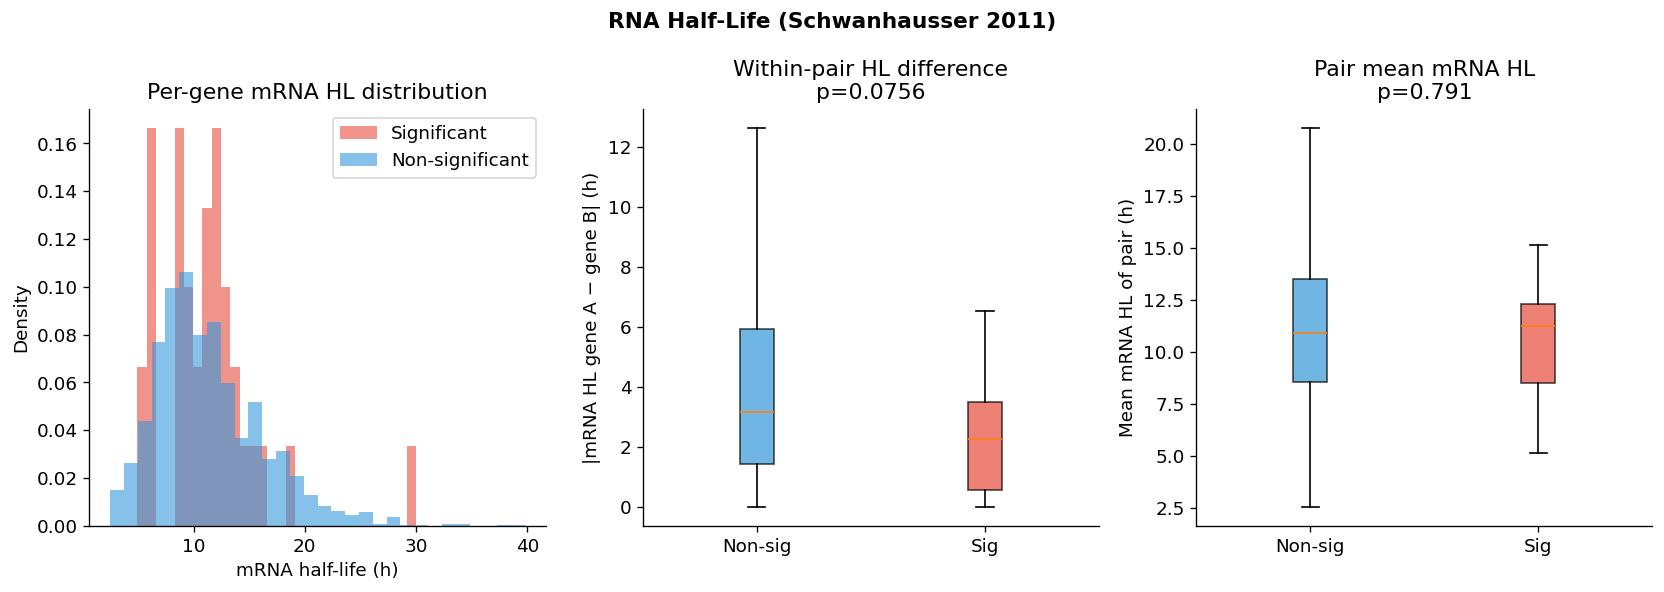

Figure saved: rna_halflife_analysis.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('RNA Half-Life (Schwanhausser 2011)', fontsize=13, fontweight='bold')

palette = {'Significant': SIG_COLOR, 'Non-significant': NSIG_COLOR}

# Per-gene HL distribution
ax = axes[0]
for grp, color in palette.items():
    subset = rhl_pairs[rhl_pairs['group'] == grp]
    vals = np.concatenate([subset['hl_A'].values, subset['hl_B'].values])
    ax.hist(vals, bins=30, alpha=0.6, color=color, label=grp, density=True)
ax.set_xlabel('mRNA half-life (h)')
ax.set_ylabel('Density')
ax.set_title('Per-gene mRNA HL distribution')
ax.legend()

# Within-pair difference
ax = axes[1]
data_box = [rhl_nsig['hl_diff'].values, rhl_sig['hl_diff'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('|mRNA HL gene A − gene B| (h)')
ax.set_title(f'Within-pair HL difference\np={r1["p-value"]:.3g}')

# Pair mean HL
ax = axes[2]
data_box = [rhl_nsig['hl_mean'].values, rhl_sig['hl_mean'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Mean mRNA HL of pair (h)')
ax.set_title(f'Pair mean mRNA HL\np={r2["p-value"]:.3g}')

plt.tight_layout()
plt.savefig('rna_halflife_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: rna_halflife_analysis.png')

## 7 · Analysis 2 — Protein Half-Life

In [11]:
phl_sig   = phl_pairs[phl_pairs['group'] == 'Significant']
phl_nsig  = phl_pairs[phl_pairs['group'] == 'Non-significant']

print(f'Protein HL pairs — sig: {len(phl_sig)}, non-sig: {len(phl_nsig)}')

r4 = mannwhitney_report(phl_sig['hl_diff'],  phl_nsig['hl_diff'],  'Protein HL | Within-pair |diff|')
r5 = mannwhitney_report(phl_sig['hl_mean'],  phl_nsig['hl_mean'],  'Protein HL | Pair mean HL')
r6 = mannwhitney_report(phl_sig[['hl_A','hl_B']].values.flatten(),
                         phl_nsig[['hl_A','hl_B']].values.flatten(),
                         'Protein HL | Per-gene HL')
all_results.extend([r4, r5, r6])

for r in [r4, r5, r6]:
    print(f"{r['Metric']:45s}  sig median={r['Sig median']:.2f}  nsig median={r['Non-sig median']:.2f}  p={r['p-value']:.4g}")

Protein HL pairs — sig: 19, non-sig: 2148
Protein HL | Within-pair |diff|                sig median=19.51  nsig median=32.62  p=0.06927
Protein HL | Pair mean HL                      sig median=50.06  nsig median=60.24  p=0.1641
Protein HL | Per-gene HL                       sig median=44.07  nsig median=56.65  p=0.2174


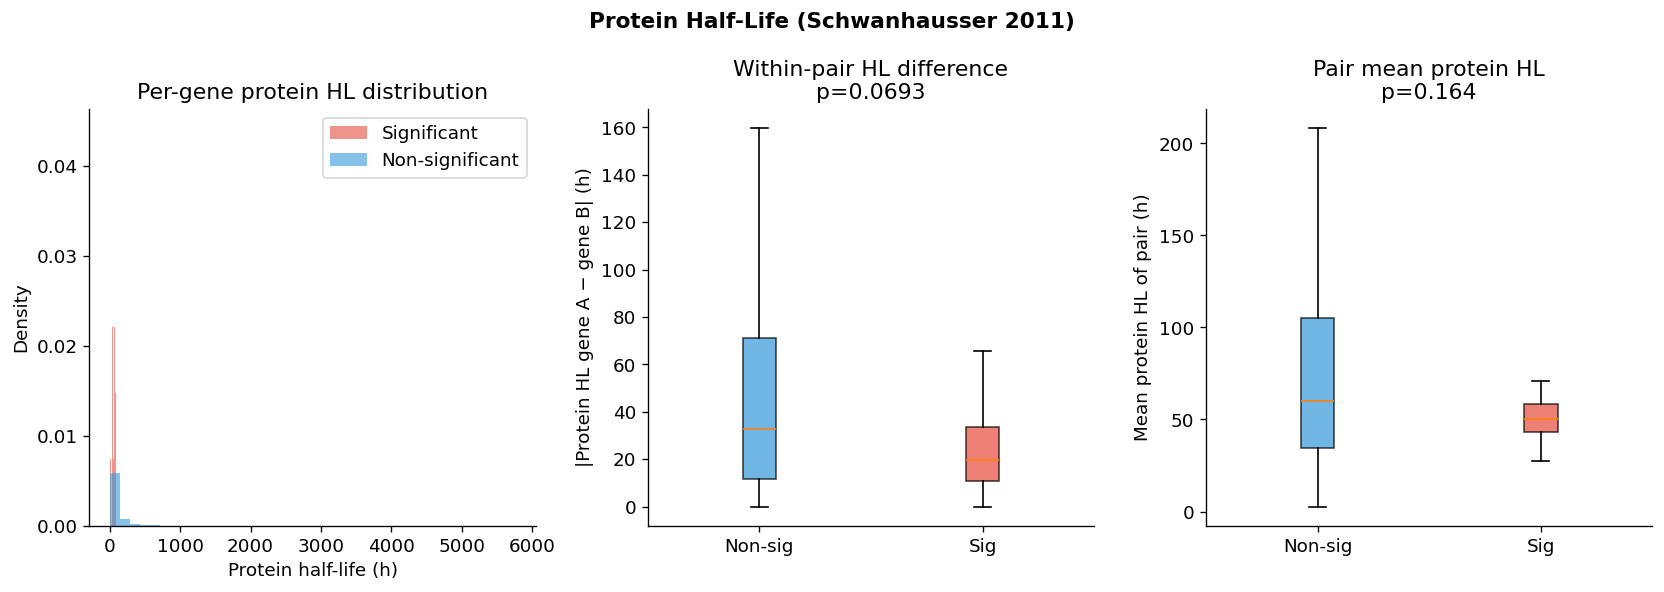

Figure saved: protein_halflife_analysis.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Protein Half-Life (Schwanhausser 2011)', fontsize=13, fontweight='bold')

# Per-gene protein HL distribution
ax = axes[0]
for grp, color in palette.items():
    subset = phl_pairs[phl_pairs['group'] == grp]
    vals = np.concatenate([subset['hl_A'].values, subset['hl_B'].values])
    ax.hist(vals, bins=40, alpha=0.6, color=color, label=grp, density=True)
ax.set_xlabel('Protein half-life (h)')
ax.set_ylabel('Density')
ax.set_title('Per-gene protein HL distribution')
ax.legend()

# Within-pair difference
ax = axes[1]
data_box = [phl_nsig['hl_diff'].values, phl_sig['hl_diff'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('|Protein HL gene A − gene B| (h)')
ax.set_title(f'Within-pair HL difference\np={r4["p-value"]:.3g}')

# Pair mean protein HL
ax = axes[2]
data_box = [phl_nsig['hl_mean'].values, phl_sig['hl_mean'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Mean protein HL of pair (h)')
ax.set_title(f'Pair mean protein HL\np={r5["p-value"]:.3g}')

plt.tight_layout()
plt.savefig('protein_halflife_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: protein_halflife_analysis.png')

## 8 · Analysis 3 — Mono-Allelic Expression

In [13]:
mae_sig   = mae_pairs[mae_pairs['group'] == 'Significant']
mae_nsig  = mae_pairs[mae_pairs['group'] == 'Non-significant']

print(f'MAE analysis — sig pairs: {len(mae_sig)}, non-sig pairs: {len(mae_nsig)}')

# ── 1. Chi-squared test on pair status distribution ───────────────────────────
status_cats = ['Both MAE', 'One MAE', 'Both BAE']
ct_sig   = mae_sig['pair_status'].value_counts().reindex(status_cats, fill_value=0)
ct_nsig  = mae_nsig['pair_status'].value_counts().reindex(status_cats, fill_value=0)

contingency = np.array([ct_sig.values, ct_nsig.values])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)

print(f'\nPair-status contingency table:')
ct_df = pd.DataFrame({'Significant': ct_sig, 'Non-significant': ct_nsig})
print(ct_df)
print(f'\nChi-squared test: χ²={chi2:.3f}, df={dof}, p={p_chi2:.4g}')

# ── 2. MAE probability comparison ────────────────────────────────────────────
sig_probs   = np.concatenate([mae_sig['prob_A'].values, mae_sig['prob_B'].values])
nsig_probs  = np.concatenate([mae_nsig['prob_A'].values, mae_nsig['prob_B'].values])

r7 = mannwhitney_report(sig_probs, nsig_probs, 'MAE | Per-gene MAE probability')

# ── 3. Concordance ────────────────────────────────────────────────────────────
r8 = mannwhitney_report(mae_sig['concordant'].values, mae_nsig['concordant'].values,
                         'MAE | Pair concordance (both same MAE/BAE)')
r8_chi = {'Metric': 'MAE | Chi-squared on pair-status distribution',
           'Sig n': len(mae_sig), 'Non-sig n': len(mae_nsig),
           'chi2': chi2, 'df': dof, 'p-value': p_chi2}

all_results.extend([r7, r8])

for r in [r7, r8]:
    print(f"{r['Metric']:50s}  sig median={r['Sig median']:.3f}  nsig median={r['Non-sig median']:.3f}  p={r['p-value']:.4g}")

MAE analysis — sig pairs: 34, non-sig pairs: 23598

Pair-status contingency table:
             Significant  Non-significant
pair_status                              
Both MAE               0            10443
One MAE                8             7366
Both BAE              26             5789

Chi-squared test: χ²=52.910, df=2, p=3.241e-12
MAE | Per-gene MAE probability                      sig median=0.060  nsig median=0.751  p=7.043e-19
MAE | Pair concordance (both same MAE/BAE)          sig median=1.000  nsig median=1.000  p=0.3338


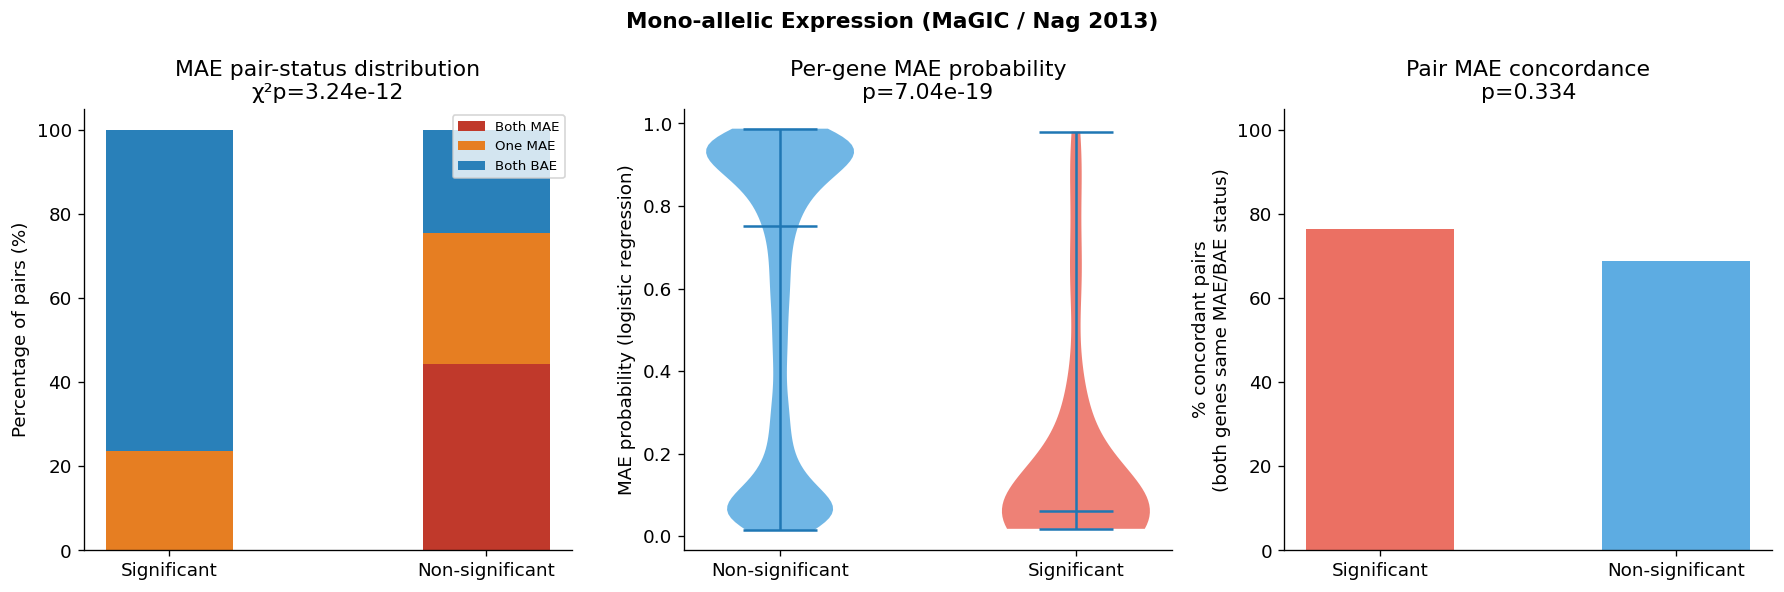

Figure saved: mae_analysis.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Mono-allelic Expression (MaGIC / Nag 2013)', fontsize=13, fontweight='bold')

# Stacked bar chart — pair status
ax = axes[0]
groups = ['Significant', 'Non-significant']
ct_pct_sig  = ct_sig / ct_sig.sum() * 100
ct_pct_nsig = ct_nsig / ct_nsig.sum() * 100

status_colors = {'Both MAE': '#C0392B', 'One MAE': '#E67E22', 'Both BAE': '#2980B9'}
bottom_sig = bottom_ns = 0
for status in status_cats:
    ax.bar([0], [ct_pct_sig[status]],  bottom=[bottom_sig], color=status_colors[status], label=status, width=0.4)
    ax.bar([1], [ct_pct_nsig[status]], bottom=[bottom_ns],  color=status_colors[status], width=0.4)
    bottom_sig += ct_pct_sig[status]
    bottom_ns  += ct_pct_nsig[status]

ax.set_xticks([0, 1])
ax.set_xticklabels(['Significant', 'Non-significant'])
ax.set_ylabel('Percentage of pairs (%)')
ax.set_title(f'MAE pair-status distribution\nχ²p={p_chi2:.3g}')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 105)

# MAE probability per gene — violin
ax = axes[1]
plot_data_mae = [
    np.concatenate([mae_nsig['prob_A'].values, mae_nsig['prob_B'].values]),
    np.concatenate([mae_sig['prob_A'].values,  mae_sig['prob_B'].values]),
]
parts = ax.violinplot(plot_data_mae, positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], [NSIG_COLOR, SIG_COLOR]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-significant', 'Significant'])
ax.set_ylabel('MAE probability (logistic regression)')
ax.set_title(f'Per-gene MAE probability\np={r7["p-value"]:.3g}')

# Concordance bar chart
ax = axes[2]
conc_sig  = mae_sig['concordant'].mean() * 100
conc_nsig = mae_nsig['concordant'].mean() * 100
ax.bar(['Significant', 'Non-significant'], [conc_sig, conc_nsig],
       color=[SIG_COLOR, NSIG_COLOR], alpha=0.8, width=0.5)
ax.set_ylabel('% concordant pairs\n(both genes same MAE/BAE status)')
ax.set_title(f'Pair MAE concordance\np={r8["p-value"]:.3g}')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('mae_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: mae_analysis.png')

## 9 · Analysis 4 — Protein Localisation

In [15]:
loc_sig   = loc_pairs[loc_pairs['group'] == 'Significant']
loc_nsig  = loc_pairs[loc_pairs['group'] == 'Non-significant']

print(f'Localisation pairs — sig: {len(loc_sig)}, non-sig: {len(loc_nsig)}')

# ── a. Jaccard similarity ─────────────────────────────────────────────────────
r9  = mannwhitney_report(loc_sig['jaccard'],      loc_nsig['jaccard'],      'Localisation | Jaccard similarity')

# ── b. Number of compartments per gene ───────────────────────────────────────
r10 = mannwhitney_report(
    np.concatenate([loc_sig['n_locs_A'].values,  loc_sig['n_locs_B'].values]),
    np.concatenate([loc_nsig['n_locs_A'].values, loc_nsig['n_locs_B'].values]),
    'Localisation | Compartment count per gene'
)
r11 = mannwhitney_report(loc_sig['n_locs_mean'],  loc_nsig['n_locs_mean'],
                          'Localisation | Mean compartment count per pair')

all_results.extend([r9, r10, r11])

for r in [r9, r10, r11]:
    print(f"{r['Metric']:55s}  sig median={r['Sig median']:.3f}  nsig median={r['Non-sig median']:.3f}  p={r['p-value']:.4g}")

Localisation pairs — sig: 25, non-sig: 13062
Localisation | Jaccard similarity                        sig median=0.500  nsig median=0.250  p=0.0075
Localisation | Compartment count per gene                sig median=2.000  nsig median=2.000  p=0.5799
Localisation | Mean compartment count per pair           sig median=2.000  nsig median=2.000  p=0.9504


In [16]:
# ── c. Per-compartment Fisher's exact test ───────────────────────────────────

def gene_has_compartment(gene_locs_series: pd.Series, compartment: str) -> np.ndarray:
    return np.array([compartment in locs for locs in gene_locs_series])

compartment_results = []
for comp in all_compartments:
    # All genes in sig pairs
    sig_genes_locs  = list(loc_sig['locs_A']) + list(loc_sig['locs_B'])
    nsig_genes_locs = list(loc_nsig['locs_A']) + list(loc_nsig['locs_B'])

    sig_in  = sum(comp in l for l in sig_genes_locs)
    sig_out = len(sig_genes_locs) - sig_in
    ns_in   = sum(comp in l for l in nsig_genes_locs)
    ns_out  = len(nsig_genes_locs) - ns_in

    table = [[sig_in, sig_out], [ns_in, ns_out]]
    _, p = fisher_exact(table, alternative='two-sided')

    compartment_results.append({
        'Compartment': comp,
        'Sig % with compartment': 100 * sig_in / len(sig_genes_locs) if sig_genes_locs else 0,
        'Non-sig % with compartment': 100 * ns_in / len(nsig_genes_locs) if nsig_genes_locs else 0,
        'Sig count': sig_in,
        'Non-sig count': ns_in,
        'p-value': p,
    })

comp_df = pd.DataFrame(compartment_results).sort_values('p-value')
comp_df['q-value (BH)'] = fdr_bh(comp_df['p-value'].tolist())
comp_df['p-value'] = comp_df['p-value'].round(4)
comp_df['q-value (BH)'] = comp_df['q-value (BH)'].round(4)

print('Per-compartment Fisher exact results (sorted by p-value):')
print(comp_df[['Compartment', 'Sig % with compartment', 'Non-sig % with compartment', 'p-value', 'q-value (BH)']].to_string(index=False))

Per-compartment Fisher exact results (sorted by p-value):
                   Compartment  Sig % with compartment  Non-sig % with compartment  p-value  q-value (BH)
           Flagellar centriole                    12.0                    1.025877   0.0000        0.0007
               Mitotic spindle                     8.0                    1.071811   0.0021        0.0516
                     End piece                    10.0                    1.982851   0.0032        0.0516
            Primary cilium tip                     8.0                    1.370387   0.0050        0.0615
                    Basal body                    12.0                    3.525494   0.0082        0.0802
            Cytokinetic bridge                     8.0                    2.266115   0.0269        0.2194
                  Microtubules                     8.0                    3.012556   0.0639        0.4276
                Primary cilium                    10.0                    4.562854   0.0773   

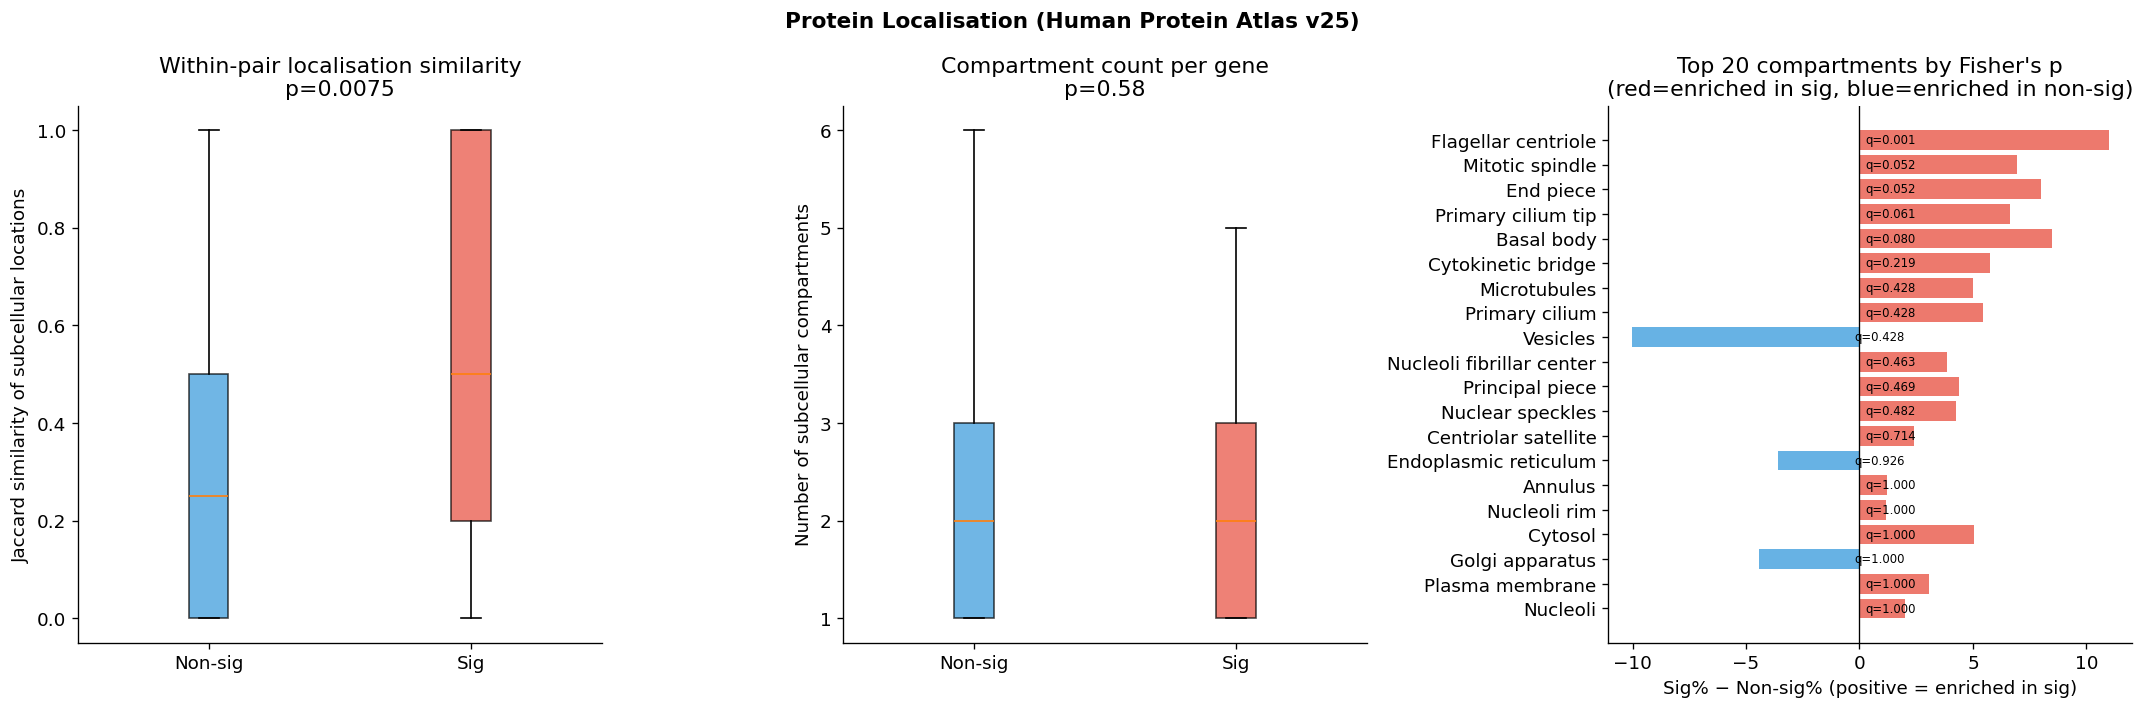

Figure saved: localisation_analysis.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Protein Localisation (Human Protein Atlas v25)', fontsize=13, fontweight='bold')

# Jaccard similarity
ax = axes[0]
data_box = [loc_nsig['jaccard'].values, loc_sig['jaccard'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Jaccard similarity of subcellular locations')
ax.set_title(f'Within-pair localisation similarity\np={r9["p-value"]:.3g}')

# Compartment count per gene
ax = axes[1]
sig_n_locs   = np.concatenate([loc_sig['n_locs_A'].values,  loc_sig['n_locs_B'].values])
nsig_n_locs  = np.concatenate([loc_nsig['n_locs_A'].values, loc_nsig['n_locs_B'].values])
data_box = [nsig_n_locs, sig_n_locs]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Number of subcellular compartments')
ax.set_title(f'Compartment count per gene\np={r10["p-value"]:.3g}')

# Per-compartment enrichment heatmap (top 20 by p-value)
ax = axes[2]
top20 = comp_df.head(20).copy()
bar_colors = [SIG_COLOR if row['Sig % with compartment'] > row['Non-sig % with compartment']
              else NSIG_COLOR for _, row in top20.iterrows()]
bars = ax.barh(
    top20['Compartment'],
    top20['Sig % with compartment'] - top20['Non-sig % with compartment'],
    color=bar_colors, alpha=0.75
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Sig% − Non-sig% (positive = enriched in sig)')
ax.set_title('Top 20 compartments by Fisher\'s p\n(red=enriched in sig, blue=enriched in non-sig)')
ax.invert_yaxis()

# Annotate q-values
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(ax.get_xlim()[1] * 0.02 if row['Sig % with compartment'] > row['Non-sig % with compartment']
            else ax.get_xlim()[0] * 0.02,
            i, f"q={row['q-value (BH)']:.3f}", va='center', fontsize=7)

plt.tight_layout()
plt.savefig('localisation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: localisation_analysis.png')

## 10 · Summary Table — All Statistical Tests

In [18]:
# Compile all results with FDR correction
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('U statistic',)}
    for r in all_results
])

summary['q-value (BH)'] = fdr_bh(summary['p-value'].tolist())

# Format
summary['Sig median']     = summary['Sig median'].round(3)
summary['Non-sig median'] = summary['Non-sig median'].round(3)
summary['p-value']        = summary['p-value'].apply(lambda x: f'{x:.4g}')
summary['q-value (BH)']   = summary['q-value (BH)'].apply(lambda x: f'{x:.4g}')

summary = summary[['Metric', 'Sig n', 'Sig median', 'Non-sig n', 'Non-sig median', 'p-value', 'q-value (BH)']]
print(summary.to_string(index=False))

summary.to_csv('statistical_summary.csv', index=False)
print('\nSummary saved: statistical_summary.csv')

                                        Metric  Sig n  Sig median  Non-sig n  Non-sig median   p-value q-value (BH)
                   RNA HL | Within-pair |diff|     18       2.265       1953           3.150   0.07561       0.2079
                         RNA HL | Pair mean HL     18      11.250       1953          10.905    0.7907       0.9504
                          RNA HL | Per-gene HL     36      11.010       3906          10.465    0.8721       0.9504
               Protein HL | Within-pair |diff|     19      19.510       2148          32.620   0.06927       0.2079
                     Protein HL | Pair mean HL     19      50.060       2148          60.238    0.1641        0.361
                      Protein HL | Per-gene HL     38      44.070       4296          56.645    0.2174       0.3986
                MAE | Per-gene MAE probability     68       0.060      47196           0.751 7.043e-19    7.747e-18
    MAE | Pair concordance (both same MAE/BAE)     34       1.000      2

In [19]:
# ── Full compartment results saved ────────────────────────────────────────────
comp_df.to_csv('localisation_compartment_results.csv', index=False)
print('Compartment-level results saved: localisation_compartment_results.csv')

Compartment-level results saved: localisation_compartment_results.csv


## 11 · Combined Summary Figure

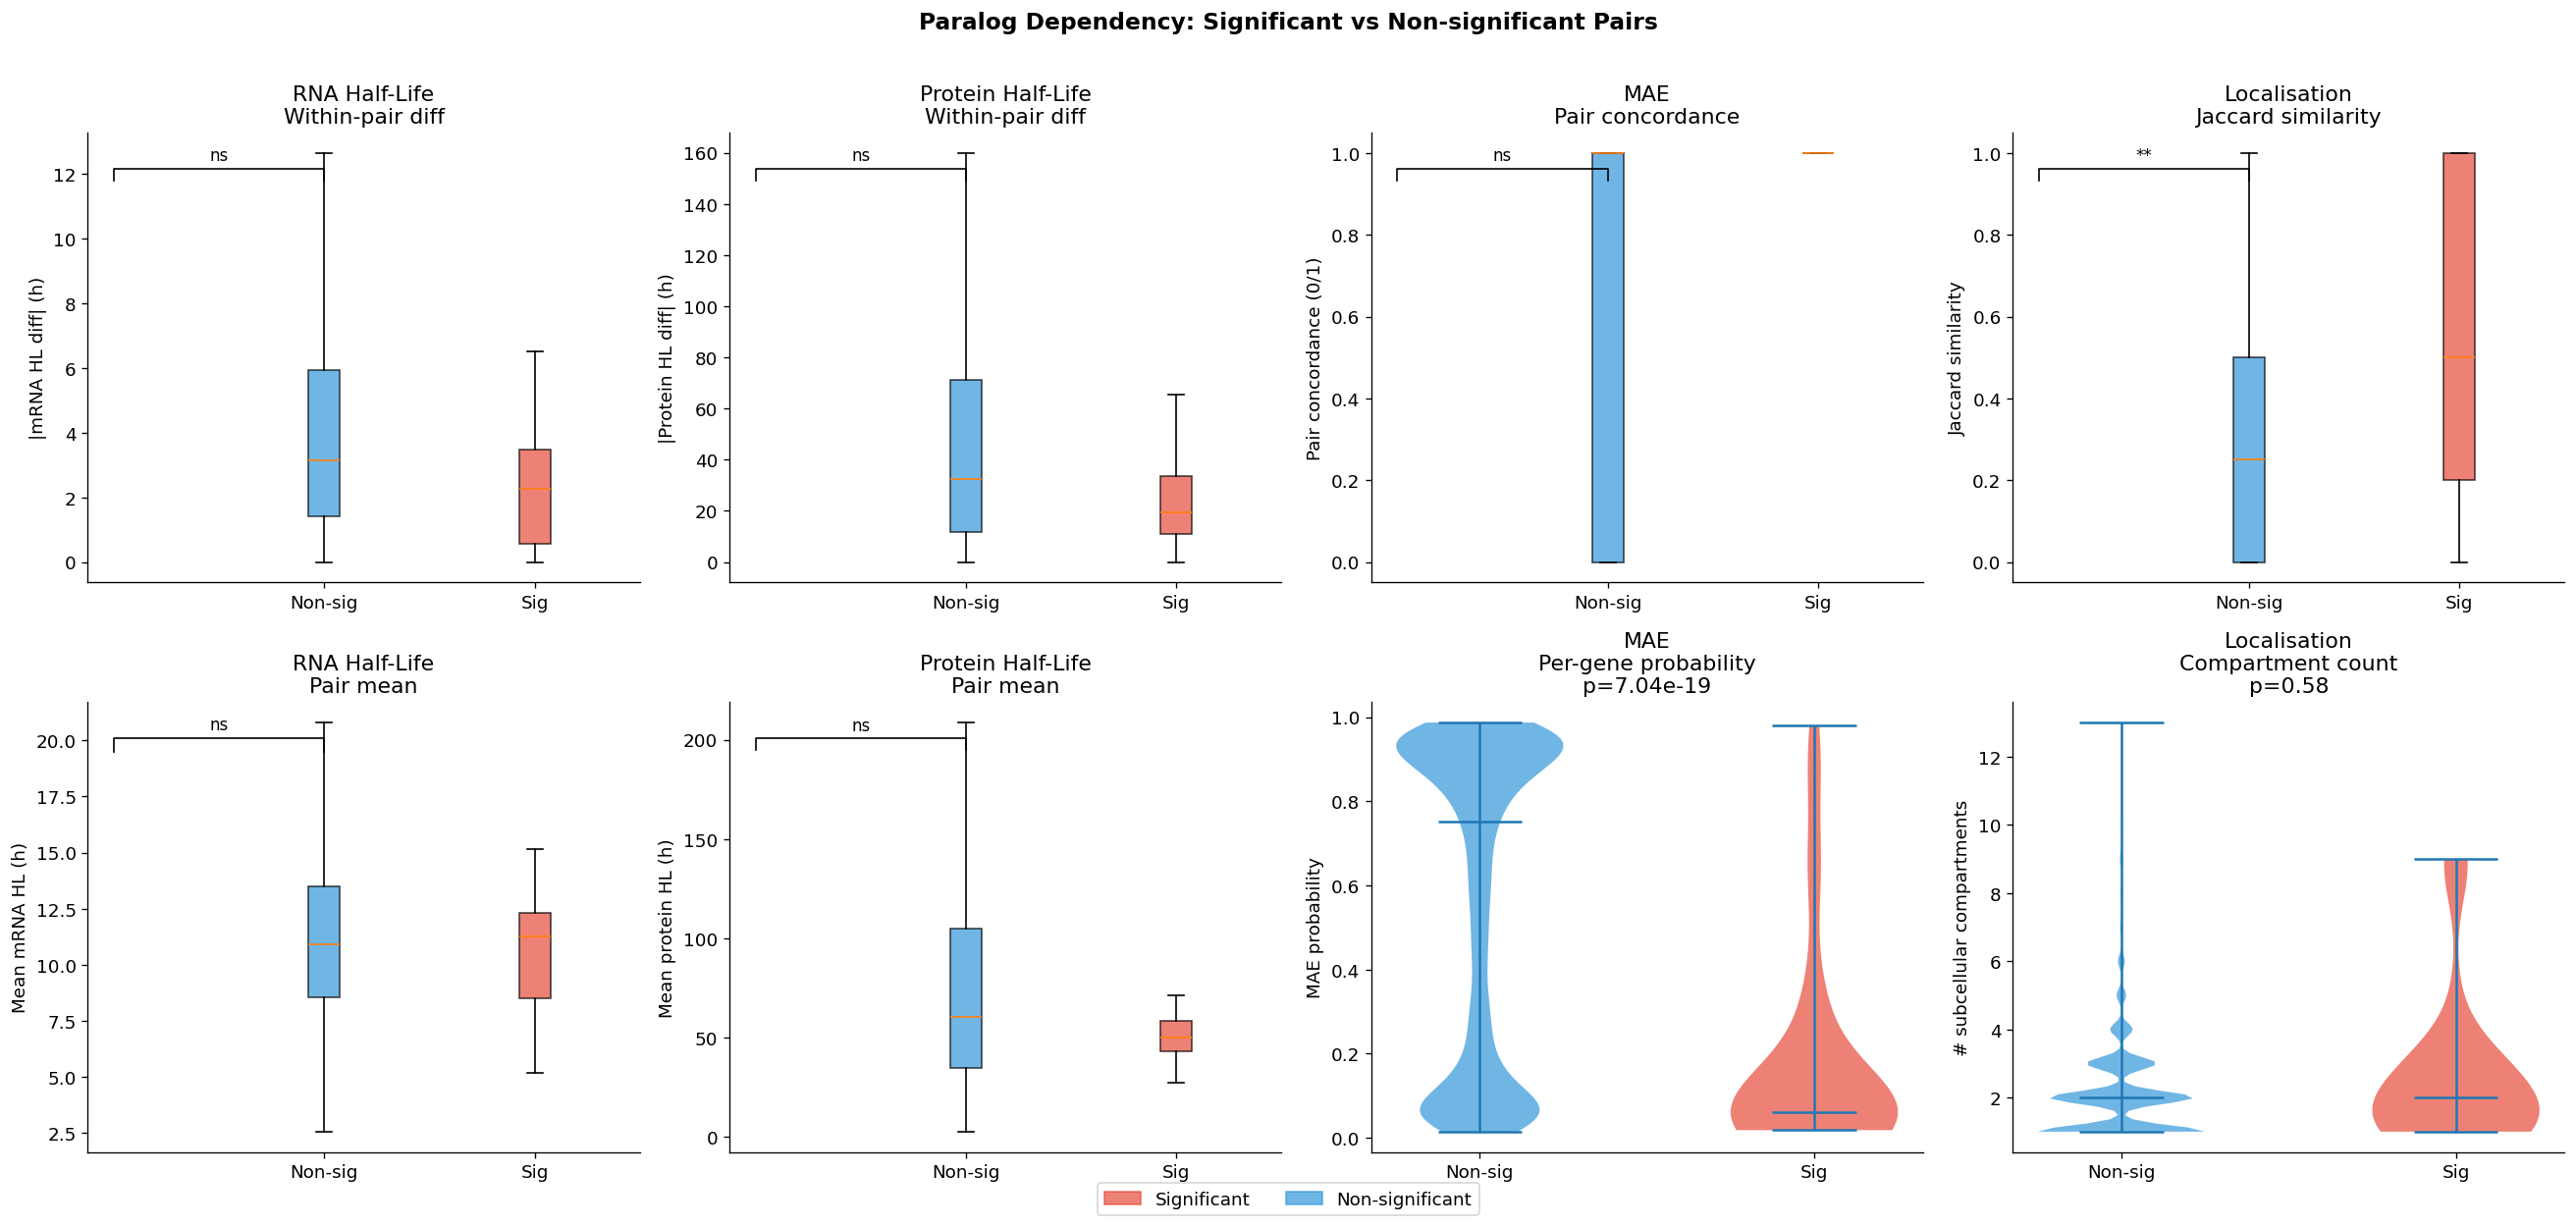

Combined figure saved: combined_summary_figure.png


In [20]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Paralog Dependency: Significant vs Non-significant Pairs', fontsize=14, fontweight='bold', y=1.01)

def add_pval(ax, p, pos1=0, pos2=1, y_offset=0.92):
    if p < 0.001: sig = '***'
    elif p < 0.01: sig = '**'
    elif p < 0.05: sig = '*'
    else: sig = 'ns'
    ylim = ax.get_ylim()
    y = ylim[0] + (ylim[1] - ylim[0]) * y_offset
    ax.plot([pos1, pos1, pos2, pos2], [y*0.97, y, y, y*0.97], lw=1, color='black')
    ax.text((pos1 + pos2) / 2, y * 1.01, sig, ha='center', va='bottom', fontsize=10)

# Helper: boxplot
def make_boxplot(ax, sig_vals, nsig_vals, ylabel, title, pval):
    bp = ax.boxplot([nsig_vals, sig_vals], labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    add_pval(ax, pval)

# Row 0: within-pair differences
make_boxplot(axes[0, 0], rhl_sig['hl_diff'].values, rhl_nsig['hl_diff'].values,
             '|mRNA HL diff| (h)', 'RNA Half-Life\nWithin-pair diff', float(r1['p-value']))
make_boxplot(axes[0, 1], phl_sig['hl_diff'].values, phl_nsig['hl_diff'].values,
             '|Protein HL diff| (h)', 'Protein Half-Life\nWithin-pair diff', float(r4['p-value']))
make_boxplot(axes[0, 2], mae_sig['concordant'].values.astype(float), mae_nsig['concordant'].values.astype(float),
             'Pair concordance (0/1)', 'MAE\nPair concordance', float(r8['p-value']))
make_boxplot(axes[0, 3], loc_sig['jaccard'].values, loc_nsig['jaccard'].values,
             'Jaccard similarity', 'Localisation\nJaccard similarity', float(r9['p-value']))

# Row 1: per-gene / mean metrics
make_boxplot(axes[1, 0], rhl_sig['hl_mean'].values, rhl_nsig['hl_mean'].values,
             'Mean mRNA HL (h)', 'RNA Half-Life\nPair mean', float(r2['p-value']))
make_boxplot(axes[1, 1], phl_sig['hl_mean'].values, phl_nsig['hl_mean'].values,
             'Mean protein HL (h)', 'Protein Half-Life\nPair mean', float(r5['p-value']))

# MAE probability violin
ax = axes[1, 2]
sig_probs_plot  = np.concatenate([mae_sig['prob_A'].values,  mae_sig['prob_B'].values])
nsig_probs_plot = np.concatenate([mae_nsig['prob_A'].values, mae_nsig['prob_B'].values])
parts = ax.violinplot([nsig_probs_plot, sig_probs_plot], positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], [NSIG_COLOR, SIG_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Non-sig', 'Sig'])
ax.set_ylabel('MAE probability')
ax.set_title(f'MAE\nPer-gene probability\np={float(r7["p-value"]):.3g}')

# Compartment count violin
ax = axes[1, 3]
sig_nlocs_plot  = np.concatenate([loc_sig['n_locs_A'].values,  loc_sig['n_locs_B'].values])
nsig_nlocs_plot = np.concatenate([loc_nsig['n_locs_A'].values, loc_nsig['n_locs_B'].values])
parts = ax.violinplot([nsig_nlocs_plot, sig_nlocs_plot], positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], [NSIG_COLOR, SIG_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Non-sig', 'Sig'])
ax.set_ylabel('# subcellular compartments')
ax.set_title(f'Localisation\nCompartment count\np={float(r10["p-value"]):.3g}')

# Legend
sig_patch  = mpatches.Patch(color=SIG_COLOR,  alpha=0.7, label='Significant')
nsig_patch = mpatches.Patch(color=NSIG_COLOR, alpha=0.7, label='Non-significant')
fig.legend(handles=[sig_patch, nsig_patch], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('combined_summary_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Combined figure saved: combined_summary_figure.png')

## 12 · Data Coverage Report

In [21]:
coverage = pd.DataFrame([
    {'Analysis': 'RNA half-life',     'Dataset': 'Schwanhausser 2011 (mouse NIH3T3)',
     'Sig pairs': len(rhl_sig), 'Non-sig pairs': len(rhl_nsig)},
    {'Analysis': 'Protein half-life', 'Dataset': 'Schwanhausser 2011 (mouse NIH3T3)',
     'Sig pairs': len(phl_sig), 'Non-sig pairs': len(phl_nsig)},
    {'Analysis': 'MAE',               'Dataset': 'MaGIC/Nag 2013 (GM12878 lymphoblast)',
     'Sig pairs': len(mae_sig), 'Non-sig pairs': len(mae_nsig)},
    {'Analysis': 'Protein localisation', 'Dataset': 'Human Protein Atlas v25',
     'Sig pairs': len(loc_sig), 'Non-sig pairs': len(loc_nsig)},
])

coverage['Sig coverage'] = (coverage['Sig pairs'] / len(sig_pairs) * 100).round(1).astype(str) + '%'
coverage['Non-sig coverage'] = (coverage['Non-sig pairs'] / len(ns_pairs) * 100).round(1).astype(str) + '%'

print('Data coverage per analysis:')
print(coverage.to_string(index=False))
print()
print('Note: Half-life datasets are from mouse cells; human-mouse gene name matching is done')
print('case-insensitively (many human/mouse genes share names). Unmatched genes are excluded.')

Data coverage per analysis:
            Analysis                              Dataset  Sig pairs  Non-sig pairs Sig coverage Non-sig coverage
       RNA half-life    Schwanhausser 2011 (mouse NIH3T3)         18           1953        48.6%             6.9%
   Protein half-life    Schwanhausser 2011 (mouse NIH3T3)         19           2148        51.4%             7.6%
                 MAE MaGIC/Nag 2013 (GM12878 lymphoblast)         34          23598        91.9%            84.0%
Protein localisation              Human Protein Atlas v25         25          13062        67.6%            46.5%

Note: Half-life datasets are from mouse cells; human-mouse gene name matching is done
case-insensitively (many human/mouse genes share names). Unmatched genes are excluded.


---

## 13 · Cancer vs Normal MAE Comparison

**Question:** Are the significant paralog genes still biallelically expressed in cancer cells, or do they acquire monoallelic chromatin signatures?

**Approach:**
1. Download fold-change-over-control BigWig files from ENCODE for **K562** (chronic myelogenous leukaemia) and **GM12878** (normal lymphoblast)
2. Compute average H3K27me3 and H3K36me3 signal over each gene body using GRCh38 RefSeq coordinates
3. Convert to percentile scores (within each cell line)
4. Apply the **same** logistic regression classifier (trained on labeled lymphoblast genes) to predict MAE/BAE in each context
5. Compare genome-wide predictions and focus on the 37 significant paralog pairs

**ENCODE files used (GRCh38):**
| Cell line | H3K27me3 | H3K36me3 |
|---|---|---|
| GM12878 (normal lymphoblast) | ENCFF543IHG | ENCFF269OIU |
| K562 (CML leukemia) | ENCFF517ZXO | ENCFF743PWK |

In [22]:
import pyBigWig

BIGWIG_DIR = DATA_DIR + 'bigwig/'

ENCODE_FILES = {
    'GM12878': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF543IHG.bigWig',
        'H3K36me3': BIGWIG_DIR + 'ENCFF269OIU.bigWig',
    },
    'K562': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF517ZXO.bigWig',
        'H3K36me3': BIGWIG_DIR + 'ENCFF743PWK.bigWig',
    },
}

# ── Load GRCh38 RefSeq gene coordinates ──────────────────────────────────────
refseq = pd.read_csv(
    DATA_DIR + 'hg38_refseq.txt', sep='\t', comment='#',
    names=['bin','name','chrom','strand','txStart','txEnd',
           'cdsStart','cdsEnd','exonCount','exonStarts','exonEnds',
           'score','name2','cdsStartStat','cdsEndStat']
)

# Keep protein-coding transcripts on standard chromosomes; one longest tx per gene
refseq = refseq[refseq['chrom'].str.match(r'^chr[\dXY]+$')]
refseq['tx_len'] = refseq['txEnd'] - refseq['txStart']
gene_coords = (
    refseq.sort_values('tx_len', ascending=False)
          .drop_duplicates(subset='name2')
          [['name2', 'chrom', 'txStart', 'txEnd']]
          .rename(columns={'name2': 'gene'})
          .reset_index(drop=True)
)

print(f'Unique genes in GRCh38 RefSeq: {len(gene_coords):,}')
print(gene_coords.head(3))


def compute_gene_body_scores(bw_path: str, coords: pd.DataFrame,
                              min_len: int = 1000) -> dict[str, float]:
    """
    For each gene in coords, compute mean fold-change signal over the gene body.
    Returns gene_name → mean_signal dict.
    """
    bw = pyBigWig.open(bw_path)
    results = {}
    bw_chroms = set(bw.chroms().keys())

    for _, row in coords.iterrows():
        chrom, start, end = row['chrom'], int(row['txStart']), int(row['txEnd'])
        if end - start < min_len:
            continue
        if chrom not in bw_chroms:
            continue
        try:
            val = bw.stats(chrom, start, end, type='mean')[0]
            if val is not None and not np.isnan(val):
                results[row['gene'].upper()] = val
        except Exception:
            pass

    bw.close()
    return results


print('\nComputing gene body scores for all 4 BigWig files...')
raw_scores: dict[str, dict[str, dict[str, float]]] = {}

for cell_line, marks in ENCODE_FILES.items():
    raw_scores[cell_line] = {}
    for mark, bw_path in marks.items():
        print(f'  {cell_line} {mark}...', end=' ', flush=True)
        s = compute_gene_body_scores(bw_path, gene_coords)
        raw_scores[cell_line][mark] = s
        print(f'{len(s):,} genes')

print('Done.')

Unique genes in GRCh38 RefSeq: 19,258
      gene chrom    txStart      txEnd
0  CNTNAP2  chr7  146116360  148420998
1    PTPRD  chr9    8314245   10612723
2      DMD  chrX   31119227   33339609

Computing gene body scores for all 4 BigWig files...
  GM12878 H3K27me3... 

18,689 genes
  GM12878 H3K36me3... 

18,689 genes
  K562 H3K27me3... 

18,689 genes
  K562 H3K36me3... 

18,688 genes
Done.


In [23]:
# ── Convert raw scores to percentiles within each cell line ──────────────────
def to_percentile_scores(score_dict: dict[str, float]) -> dict[str, float]:
    """Convert raw BigWig means to percentile ranks (0–1) within the cell line."""
    genes  = list(score_dict.keys())
    values = np.array([score_dict[g] for g in genes])
    from scipy.stats import rankdata
    pct = rankdata(values) / len(values)
    return dict(zip(genes, pct))


cell_line_scores: dict[str, pd.DataFrame] = {}

for cell_line in ENCODE_FILES:
    h27 = raw_scores[cell_line]['H3K27me3']
    h36 = raw_scores[cell_line]['H3K36me3']

    h27_pct = to_percentile_scores(h27)
    h36_pct = to_percentile_scores(h36)

    common_genes = set(h27_pct) & set(h36_pct)
    df = pd.DataFrame({
        'gene': list(common_genes),
        'h3k27me3_percentile': [h27_pct[g] for g in common_genes],
        'h3k36me3_percentile': [h36_pct[g] for g in common_genes],
    })

    # Apply classifier
    X = scaler.transform(df[['h3k27me3_percentile', 'h3k36me3_percentile']].values)
    df['mae_pred'] = clf.predict(X).astype(int)
    df['mae_prob'] = clf.predict_proba(X)[:, 1]

    cell_line_scores[cell_line] = df
    n_mae = df['mae_pred'].sum()
    print(f'{cell_line}: {len(df):,} genes scored  |  '
          f'MAE predicted: {n_mae:,} ({100*n_mae/len(df):.1f}%)  '
          f'BAE: {len(df)-n_mae:,} ({100*(len(df)-n_mae)/len(df):.1f}%)')

GM12878: 18,689 genes scored  |  MAE predicted: 9,224 (49.4%)  BAE: 9,465 (50.6%)
K562: 18,688 genes scored  |  MAE predicted: 8,837 (47.3%)  BAE: 9,851 (52.7%)


In [24]:
# ── Merge GM12878 and K562 predictions on shared genes ───────────────────────
gm = cell_line_scores['GM12878'].rename(columns={
    'mae_pred': 'mae_pred_gm', 'mae_prob': 'mae_prob_gm',
    'h3k27me3_percentile': 'h3k27me3_gm', 'h3k36me3_percentile': 'h3k36me3_gm',
})
k5 = cell_line_scores['K562'].rename(columns={
    'mae_pred': 'mae_pred_k5', 'mae_prob': 'mae_prob_k5',
    'h3k27me3_percentile': 'h3k27me3_k5', 'h3k36me3_percentile': 'h3k36me3_k5',
})

comparison = gm.merge(k5, on='gene', how='inner')

# Classify switching behaviour
def switching(row):
    gm, k5 = row['mae_pred_gm'], row['mae_pred_k5']
    if   gm == 0 and k5 == 0: return 'BAE in both'
    elif gm == 1 and k5 == 1: return 'MAE in both'
    elif gm == 0 and k5 == 1: return 'BAE→MAE (gained in cancer)'
    else:                       return 'MAE→BAE (lost in cancer)'

comparison['switch'] = comparison.apply(switching, axis=1)

print(f'Genes with predictions in both cell lines: {len(comparison):,}')
print()
print(comparison['switch'].value_counts().to_string())
print()
print(f'Overall MAE rate — GM12878: {comparison["mae_pred_gm"].mean()*100:.1f}%'
      f'  |  K562: {comparison["mae_pred_k5"].mean()*100:.1f}%')

Genes with predictions in both cell lines: 18,688

switch
BAE in both                   7967
MAE in both                   7339
MAE→BAE (lost in cancer)      1884
BAE→MAE (gained in cancer)    1498

Overall MAE rate — GM12878: 49.4%  |  K562: 47.3%


In [25]:
# ── Focus on the paralog genes ───────────────────────────────────────────────
sig_genes_upper  = set(sig_pairs['gene_A'].str.upper()) | set(sig_pairs['gene_B'].str.upper())
nsig_genes_upper = set(ns_pairs['gene_A'].str.upper()) | set(ns_pairs['gene_B'].str.upper())

comparison['is_sig_paralog']  = comparison['gene'].isin(sig_genes_upper)
comparison['is_nsig_paralog'] = comparison['gene'].isin(nsig_genes_upper)

sig_comp  = comparison[comparison['is_sig_paralog']]
nsig_comp = comparison[comparison['is_nsig_paralog']]

print('=== Significant paralog genes ===')
print(f'  Total sig genes: {len(sig_genes_upper)},  found in comparison: {len(sig_comp)}')
print()
print(sig_comp[['gene','mae_prob_gm','mae_pred_gm','mae_prob_k5','mae_pred_k5','switch']]
      .sort_values('mae_prob_gm').to_string(index=False))

print()
print('=== Switching summary for significant paralog genes ===')
print(sig_comp['switch'].value_counts().to_string())
print()
print('=== Switching summary for non-significant paralog genes ===')
print(nsig_comp['switch'].value_counts().to_string())

=== Significant paralog genes ===
  Total sig genes: 69,  found in comparison: 69

    gene  mae_prob_gm  mae_pred_gm  mae_prob_k5  mae_pred_k5                   switch
  DDX39B     0.014812            0     0.136774            0              BAE in both
    EIF1     0.017779            0     0.178572            0              BAE in both
 HNRNPH1     0.019268            0     0.072451            0              BAE in both
    TUBB     0.022142            0     0.137373            0              BAE in both
   MAGOH     0.022303            0     0.031722            0              BAE in both
 SMARCA2     0.022649            0     0.091405            0              BAE in both
  EIF1AX     0.023839            0     0.027799            0              BAE in both
   DDX17     0.027413            0     0.051321            0              BAE in both
    DDX5     0.028434            0     0.058998            0              BAE in both
  HNRNPU     0.031015            0     0.063451          

In [26]:
# ── Statistical tests: MAE probability in cancer vs normal ───────────────────

# 1. For sig paralog genes: does MAE probability change from GM12878 → K562?
from scipy.stats import wilcoxon

sig_gm_probs = sig_comp['mae_prob_gm'].values
sig_k5_probs = sig_comp['mae_prob_k5'].values
_, p_sig_switch = wilcoxon(sig_gm_probs, sig_k5_probs)

nsig_gm_probs = nsig_comp['mae_prob_gm'].values
nsig_k5_probs = nsig_comp['mae_prob_k5'].values
_, p_nsig_switch = wilcoxon(nsig_gm_probs, nsig_k5_probs)

print('=== MAE probability shift: Normal (GM12878) → Cancer (K562) ===')
print(f'Sig paralog genes:')
print(f'  GM12878 median prob = {np.median(sig_gm_probs):.3f}')
print(f'  K562    median prob = {np.median(sig_k5_probs):.3f}')
print(f'  Wilcoxon signed-rank p = {p_sig_switch:.4g}')
print()
print(f'Non-sig paralog genes:')
print(f'  GM12878 median prob = {np.median(nsig_gm_probs):.3f}')
print(f'  K562    median prob = {np.median(nsig_k5_probs):.3f}')
print(f'  Wilcoxon signed-rank p = {p_nsig_switch:.4g}')
print()

# 2. In K562: do sig genes remain more BAE than non-sig genes?
r_cancer = mannwhitney_report(
    sig_comp['mae_prob_k5'].values,
    nsig_comp['mae_prob_k5'].values,
    'K562 (cancer) | Sig vs Non-sig MAE probability'
)
r_normal = mannwhitney_report(
    sig_comp['mae_prob_gm'].values,
    nsig_comp['mae_prob_gm'].values,
    'GM12878 (normal, recomputed) | Sig vs Non-sig MAE probability'
)

for r in [r_cancer, r_normal]:
    print(f"{r['Metric']}")
    print(f"  sig median={r['Sig median']:.3f}  nsig median={r['Non-sig median']:.3f}  p={r['p-value']:.4g}")

=== MAE probability shift: Normal (GM12878) → Cancer (K562) ===
Sig paralog genes:
  GM12878 median prob = 0.096
  K562    median prob = 0.115
  Wilcoxon signed-rank p = 0.1914

Non-sig paralog genes:


  GM12878 median prob = 0.607
  K562    median prob = 0.542
  Wilcoxon signed-rank p = 0.1525

K562 (cancer) | Sig vs Non-sig MAE probability
  sig median=0.115  nsig median=0.542  p=1.009e-13
GM12878 (normal, recomputed) | Sig vs Non-sig MAE probability
  sig median=0.096  nsig median=0.607  p=2.017e-14


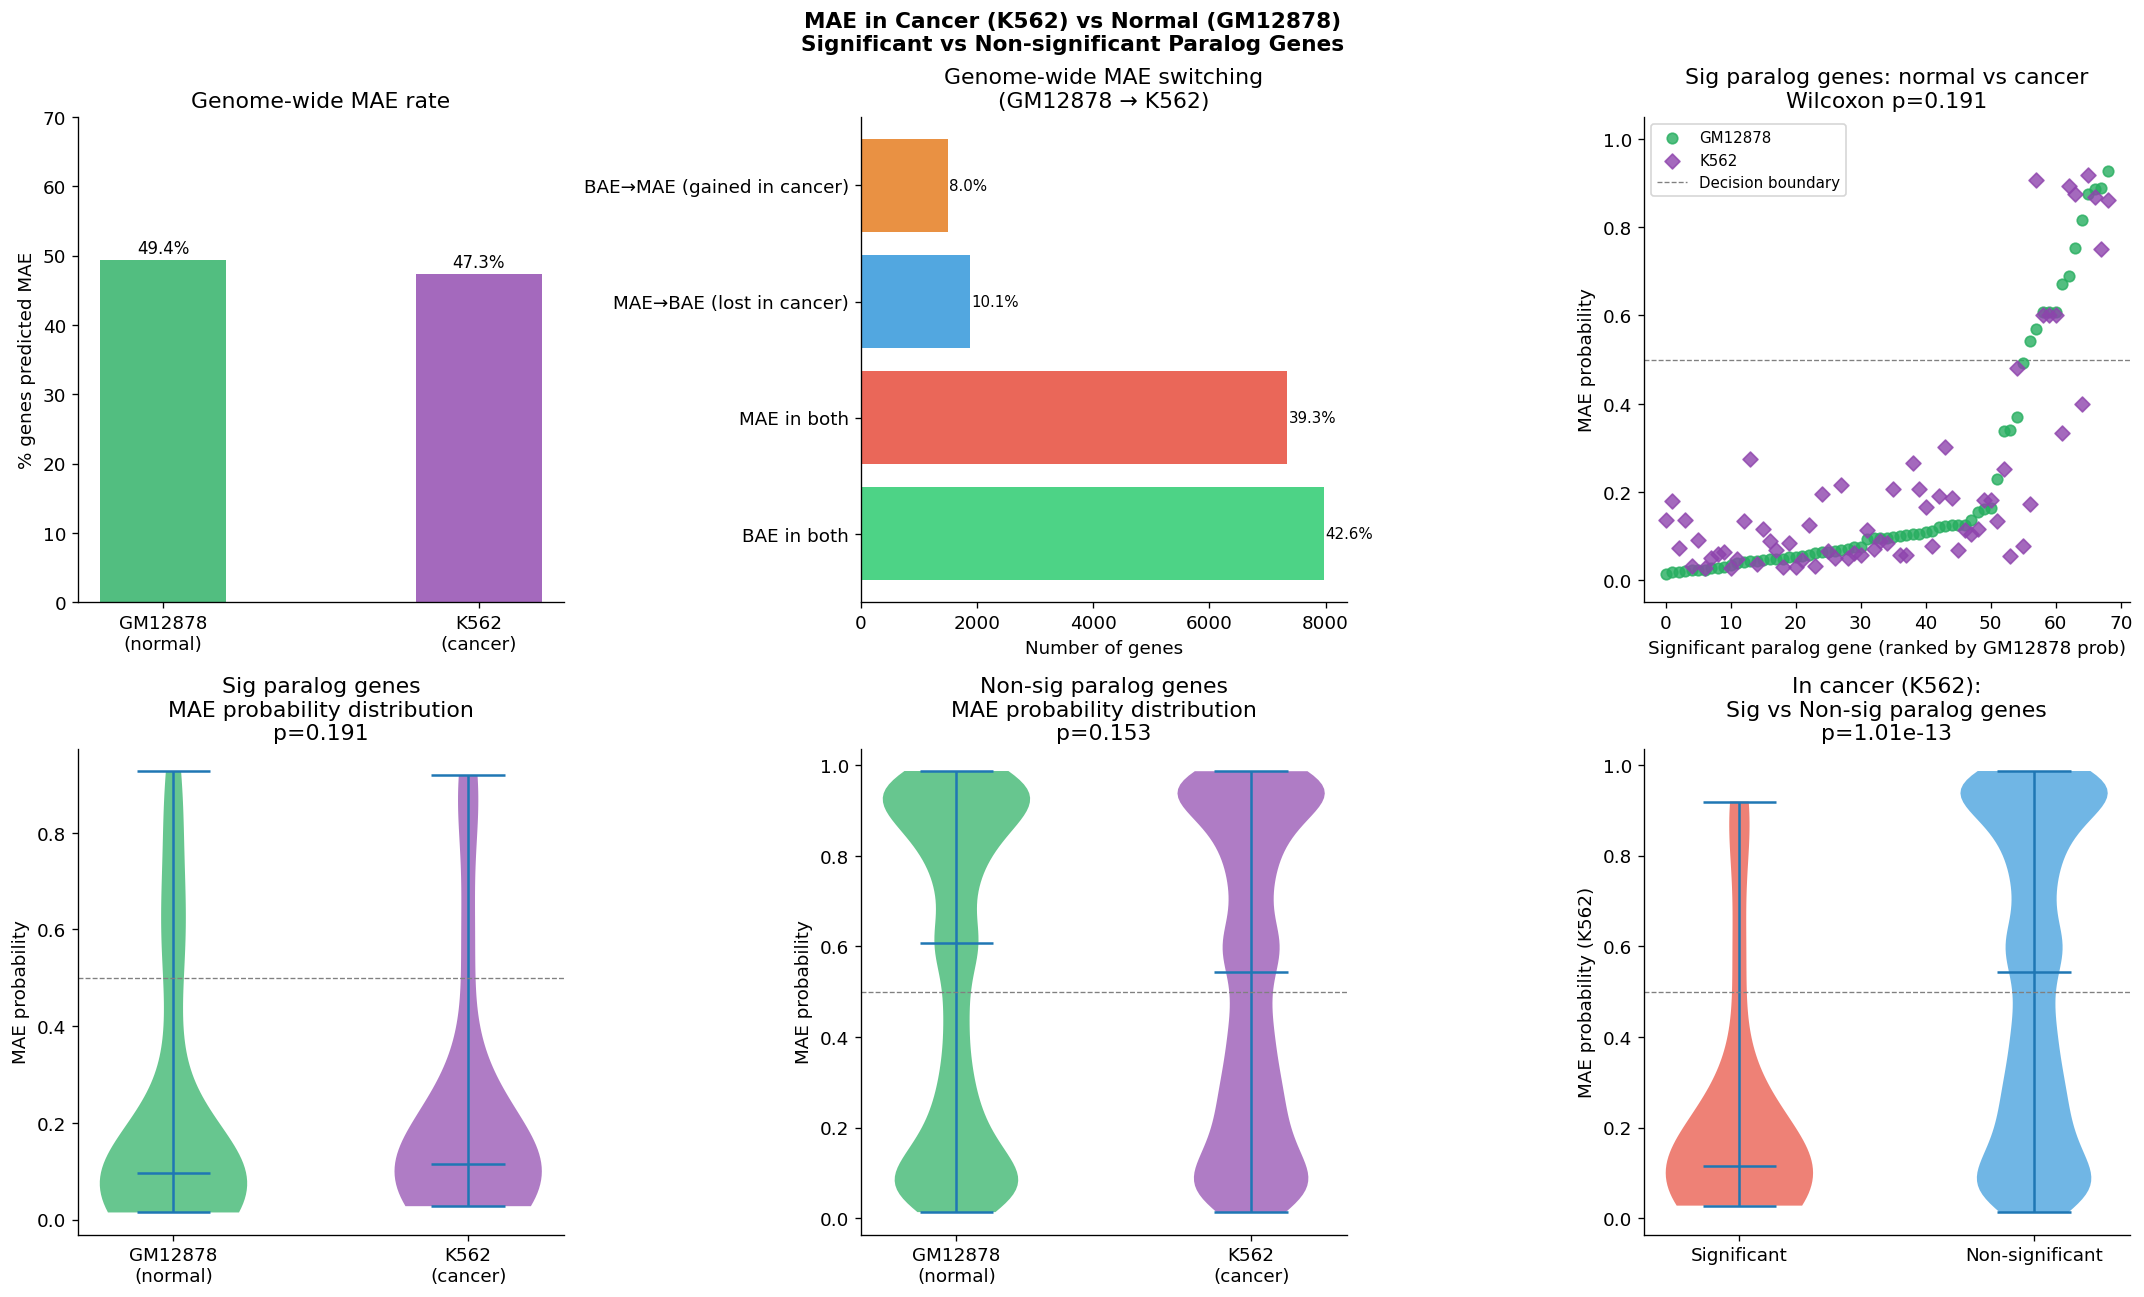

Figure saved: cancer_mae_analysis.png
Data saved: cancer_vs_normal_mae_comparison.csv


In [27]:
# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('MAE in Cancer (K562) vs Normal (GM12878)\nSignificant vs Non-significant Paralog Genes',
             fontsize=13, fontweight='bold')

CANCER_COLOR = '#8E44AD'   # purple – K562
NORMAL_COLOR = '#27AE60'   # green  – GM12878

# ── Panel 1: Genome-wide MAE prediction rate bar chart ───────────────────────
ax = axes[0, 0]
rates = {
    'GM12878\n(normal)': comparison['mae_pred_gm'].mean() * 100,
    'K562\n(cancer)': comparison['mae_pred_k5'].mean() * 100,
}
bars = ax.bar(rates.keys(), rates.values(), color=[NORMAL_COLOR, CANCER_COLOR], alpha=0.8, width=0.4)
ax.set_ylabel('% genes predicted MAE')
ax.set_title('Genome-wide MAE rate')
ax.set_ylim(0, 70)
for bar, val in zip(bars, rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

# ── Panel 2: Switching categories pie / bar ───────────────────────────────────
ax = axes[0, 1]
switch_counts = comparison['switch'].value_counts()
switch_colors = {
    'BAE in both': '#2ECC71',
    'MAE in both': '#E74C3C',
    'BAE→MAE (gained in cancer)': '#E67E22',
    'MAE→BAE (lost in cancer)': '#3498DB',
}
bars2 = ax.barh(
    switch_counts.index, switch_counts.values,
    color=[switch_colors.get(k, 'grey') for k in switch_counts.index],
    alpha=0.85
)
ax.set_xlabel('Number of genes')
ax.set_title('Genome-wide MAE switching\n(GM12878 → K562)')
for bar, val in zip(bars2, switch_counts.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{100*val/len(comparison):.1f}%', va='center', fontsize=9)

# ── Panel 3: MAE probability — sig paralog genes, normal vs cancer ─────────────
ax = axes[0, 2]
x = np.arange(len(sig_comp))
ax.scatter(x, sig_comp.sort_values('mae_prob_gm')['mae_prob_gm'].values,
           color=NORMAL_COLOR, label='GM12878', s=40, alpha=0.8, zorder=3)
ax.scatter(x, sig_comp.sort_values('mae_prob_gm')['mae_prob_k5'].values,
           color=CANCER_COLOR, label='K562', s=40, marker='D', alpha=0.8, zorder=3)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Decision boundary')
ax.set_xlabel('Significant paralog gene (ranked by GM12878 prob)')
ax.set_ylabel('MAE probability')
ax.set_title(f'Sig paralog genes: normal vs cancer\nWilcoxon p={p_sig_switch:.3g}')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

# ── Panel 4: Violin — MAE prob in GM12878 vs K562, sig genes ─────────────────
ax = axes[1, 0]
parts = ax.violinplot(
    [sig_comp['mae_prob_gm'].values, sig_comp['mae_prob_k5'].values],
    positions=[0, 1], showmedians=True
)
for pc, color in zip(parts['bodies'], [NORMAL_COLOR, CANCER_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['GM12878\n(normal)', 'K562\n(cancer)'])
ax.set_ylabel('MAE probability')
ax.set_title(f'Sig paralog genes\nMAE probability distribution\np={p_sig_switch:.3g}')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)

# ── Panel 5: Violin — MAE prob in GM12878 vs K562, non-sig genes ─────────────
ax = axes[1, 1]
parts = ax.violinplot(
    [nsig_comp['mae_prob_gm'].values, nsig_comp['mae_prob_k5'].values],
    positions=[0, 1], showmedians=True
)
for pc, color in zip(parts['bodies'], [NORMAL_COLOR, CANCER_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['GM12878\n(normal)', 'K562\n(cancer)'])
ax.set_ylabel('MAE probability')
ax.set_title(f'Non-sig paralog genes\nMAE probability distribution\np={p_nsig_switch:.3g}')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)

# ── Panel 6: Side-by-side — sig vs non-sig in K562 ───────────────────────────
ax = axes[1, 2]
parts = ax.violinplot(
    [sig_comp['mae_prob_k5'].values, nsig_comp['mae_prob_k5'].values],
    positions=[0, 1], showmedians=True
)
for pc, color in zip(parts['bodies'], [SIG_COLOR, NSIG_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Significant', 'Non-significant'])
ax.set_ylabel('MAE probability (K562)')
ax.set_title(f'In cancer (K562):\nSig vs Non-sig paralog genes\np={r_cancer["p-value"]:.3g}')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('cancer_mae_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: cancer_mae_analysis.png')

# Save full comparison table
comparison.to_csv('cancer_vs_normal_mae_comparison.csv', index=False)
print('Data saved: cancer_vs_normal_mae_comparison.csv')